In [1]:
from transformers import CLIPProcessor, CLIPModel
from PIL import Image
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt

c:\Users\akshi\OneDrive\Desktop\zero-shot-industrial-anomaly-detection\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")

processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

Loading weights: 100%|██████████| 398/398 [00:00<00:00, 34940.10it/s]


In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = model.to(device)

print("Using device:", device)

Using device: cpu


In [4]:
def get_patch_embeddings(
    patches,
    model,
    processor,
    batch_size=64
):

    all_features = []

    for i in range(0, len(patches), batch_size):

        batch_patches = patches[i:i + batch_size]

        patch_images = []

        for patch in batch_patches:

            patch = patch.astype(np.uint8)

            if len(patch.shape) == 2:

                patch = cv2.cvtColor(
                    patch,
                    cv2.COLOR_GRAY2RGB
                )

            patch_images.append(
                Image.fromarray(patch)
            )

        inputs = processor(
            images=patch_images,
            return_tensors="pt",
            padding=True
        )

        inputs = {
            key: value.to(device)
            for key, value in inputs.items()
        }

        with torch.no_grad():

            outputs = model.vision_model(
                pixel_values=inputs["pixel_values"]
            )

            batch_features = outputs.pooler_output

        batch_features = batch_features / torch.norm(
            batch_features,
            dim=-1,
            keepdim=True
        )

        all_features.append(batch_features)

    return torch.cat(all_features, dim=0)

In [5]:
def extract_overlapping_patches(
    image,
    patch_size=64,
    stride=32
):

    patches = []
    positions = []

    h, w = image.shape[:2]

    for y in range(0, h - patch_size + 1, stride):

        for x in range(0, w - patch_size + 1, stride):

            patch = image[
                y:y + patch_size,
                x:x + patch_size
            ]

            patches.append(patch)

            positions.append((x, y))

    return patches, positions

In [6]:
image_path = "../data/raw/mvtec_anomaly_detection/bottle/test/broken_large/000.png"

image = Image.open(image_path).convert("RGB")

image_np = np.array(image)

print(image_np.shape)

(900, 900, 3)


In [7]:
patches, positions = extract_overlapping_patches(
    image_np,
    patch_size=64,
    stride=32
)

print("Total patches:", len(patches))

Total patches: 729


In [8]:
reference_image_paths = [

    "../data/raw/mvtec_anomaly_detection/bottle/train/good/000.png",

    "../data/raw/mvtec_anomaly_detection/bottle/train/good/001.png",

    "../data/raw/mvtec_anomaly_detection/bottle/train/good/002.png",

    "../data/raw/mvtec_anomaly_detection/bottle/train/good/003.png"
]

reference_images = [

    Image.open(path).convert("RGB")

    for path in reference_image_paths
]

print("Total reference images:", len(reference_images))

Total reference images: 4


In [9]:
all_reference_patches = []

for ref_image in reference_images:

    ref_np = np.array(ref_image)

    ref_patches, _ = extract_overlapping_patches(
        ref_np,
        patch_size=64,
        stride=32
    )

    all_reference_patches.append(ref_patches)

In [10]:
all_reference_embeddings = []

for ref_patches in all_reference_patches:

    ref_embeddings = get_patch_embeddings(
        ref_patches,
        model,
        processor
    )

    all_reference_embeddings.append(ref_embeddings)

In [11]:
reference_stack = torch.stack(
    all_reference_embeddings
)

print(reference_stack.shape)

torch.Size([4, 729, 768])


In [12]:
mean_reference_embedding = torch.mean(
    reference_stack,
    dim=0
)

print(mean_reference_embedding.shape)

torch.Size([729, 768])


In [13]:
patch_embeddings = get_patch_embeddings(
    patches,
    model,
    processor
)

In [14]:
import torch.nn.functional as F

cosine_scores = F.cosine_similarity(
    patch_embeddings,
    mean_reference_embedding,
    dim=1
)

In [15]:
anomaly_scores = (
    1 - cosine_scores.cpu().numpy()
)

anomaly_scores = (
    anomaly_scores - anomaly_scores.min()
) / (
    anomaly_scores.max() - anomaly_scores.min() + 1e-8
)

anomaly_scores = anomaly_scores ** 3

In [16]:
heatmap = np.zeros(
    (image_np.shape[0], image_np.shape[1])
)

count_map = np.zeros_like(heatmap)

patch_size = 64

for score, (x, y) in zip(anomaly_scores, positions):

    heatmap[
        y:y + patch_size,
        x:x + patch_size
    ] += score

    count_map[
        y:y + patch_size,
        x:x + patch_size
    ] += 1

heatmap = heatmap / (
    count_map + 1e-8
)

In [17]:
epsilon = 1e-8

heatmap_normalized = (
    heatmap - heatmap.min()
) / (
    heatmap.max() - heatmap.min() + epsilon
)

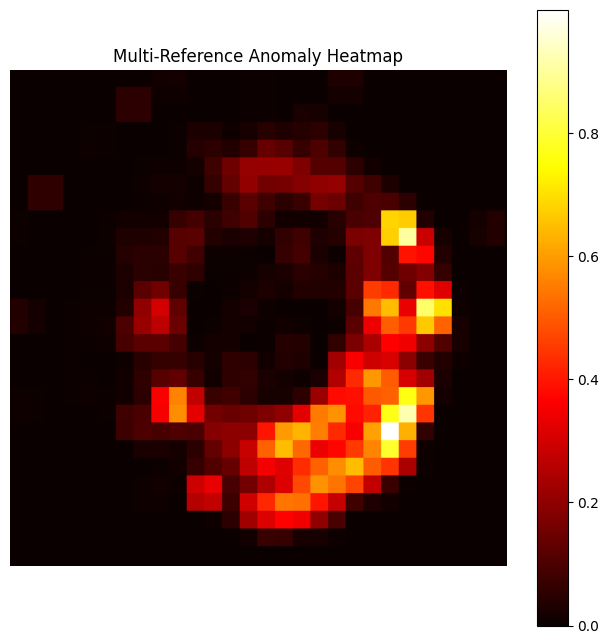

In [18]:
plt.figure(figsize=(8,8))

plt.imshow(
    heatmap_normalized,
    cmap="hot"
)

plt.colorbar()

plt.title(
    "Multi-Reference Anomaly Heatmap"
)

plt.axis("off")

plt.show()

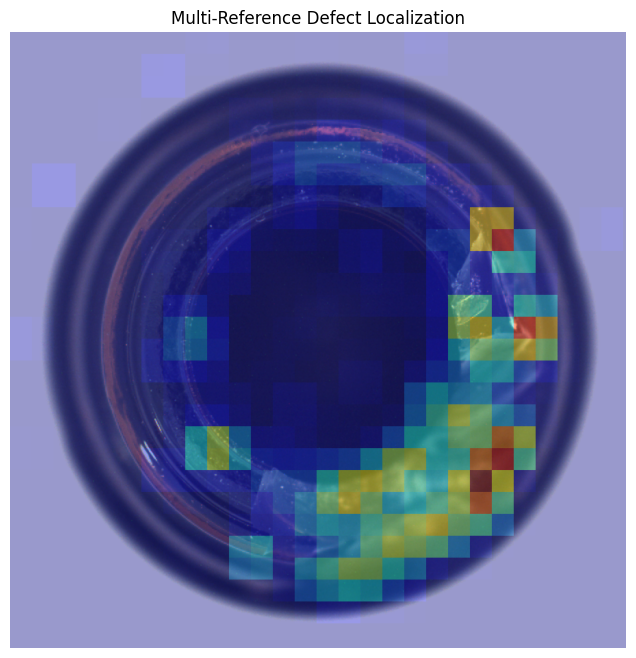

In [19]:
heatmap_colored = cv2.applyColorMap(
    np.uint8(255 * heatmap_normalized),
    cv2.COLORMAP_JET
)

heatmap_colored = cv2.cvtColor(
    heatmap_colored,
    cv2.COLOR_BGR2RGB
)

overlay = cv2.addWeighted(
    image_np,
    0.6,
    heatmap_colored,
    0.4,
    0
)

plt.figure(figsize=(8,8))

plt.imshow(overlay)

plt.title(
    "Multi-Reference Defect Localization"
)

plt.axis("off")

plt.show()